In [6]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\naila\OneDrive\Documentos\ironhack\lab-eda-bivariate\amz_uk_price_prediction_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\naila\\OneDrive\\Documentos\\ironhack\\lab-eda-bivariate\\amz_uk_price_prediction_dataset.csv'

In [ ]:
# Part 1: Product Categories
category_counts = df['category'].value_counts()
top_5_categories = category_counts.head(5)
print("Top 5 Categorías:\n", top_5_categories)

Top 5 Categorías:
 category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


C:\Users\naila\AppData\Local\Temp\ipykernel_15156\559697358.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.head(10).values, y=category_counts.head(10).index, palette='magma')


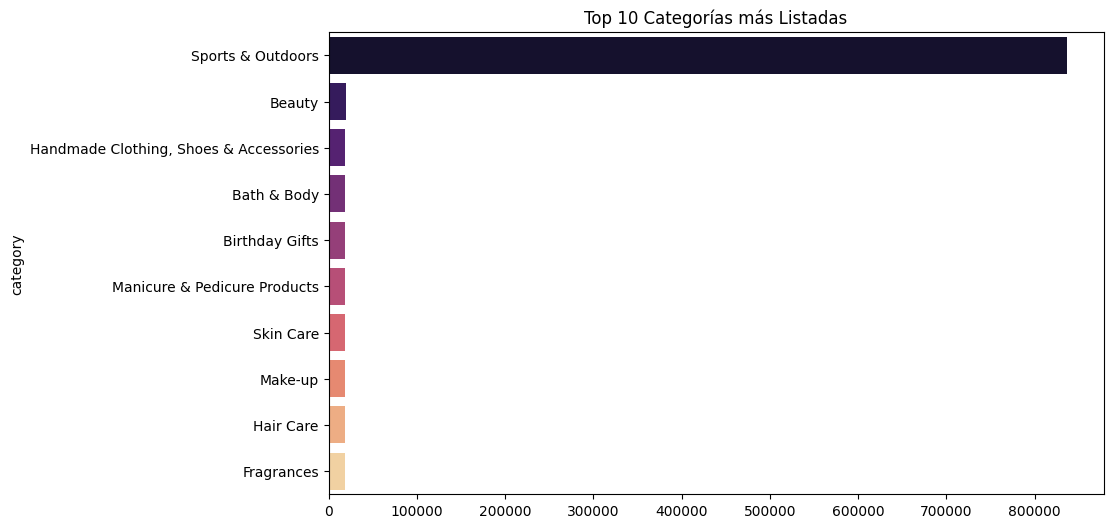

In [ ]:
# Visualización: Barras para Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.head(10).values, y=category_counts.head(10).index, palette='magma')
plt.title('Top 10 Categorías más Listadas')
plt.show()

Bar Chart: Muestra una clara dominancia de productos de Sports y Outdoors.

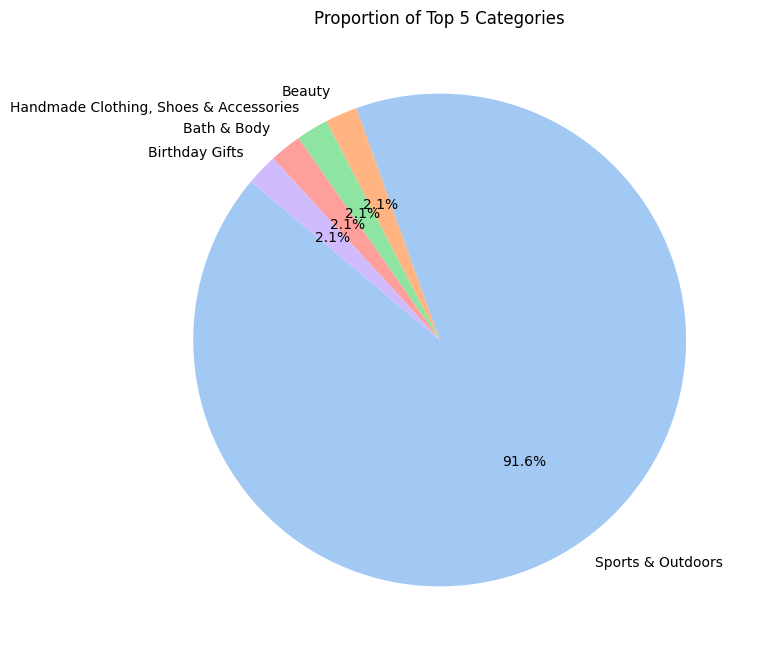

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(top_5_categories, labels=top_5_categories.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Top 5 Categories')
plt.show()

Pie Chart: La categoría Sports & Outdoors abarca casi un tercio de los listados totales entre las top 5, dominando claramente el inventario. 

In [ ]:
# Part 2: Pricing

# ==========================================
# 0. LIMPIEZA DE DATOS (MÉTODO IQR PARA PRECIO)
# ==========================================

# Cálculo de límites para eliminar outliers de precio
q1: float = df['price'].quantile(0.25)
q3: float = df['price'].quantile(0.75)
iqr: float = q3 - q1

lower_bound: float = q1 - 1.5 * iqr
upper_bound: float = q3 + 1.5 * iqr

# Creamos el DataFrame limpio filtrando únicamente outliers de precio
df_clean: pd.DataFrame = df[
    (df['price'] >= lower_bound) & 
    (df['price'] <= upper_bound)
].copy()


# ==========================================
# 1. MEDIDAS DE CENTRALIDAD Y DISPERSIÓN (PRECIO)
# ==========================================

# Extraemos la serie de precios ya limpia
price_data: pd.Series = df_clean['price']

price_stats: dict[str, float] = {
    'mean': float(price_data.mean()),
    'median': float(price_data.median()),
    'mode': float(price_data.mode()[0]),
    'variance': float(price_data.var()),
    'std_dev': float(price_data.std()),
    'range': float(price_data.max() - price_data.min()),
    'iqr': float(price_data.quantile(0.75) - price_data.quantile(0.25))
}

print("--- ESTADÍSTICAS DE PRECIO (DATOS LIMPIOS) ---")
for metric, value in price_stats.items():
    print(f"{metric.capitalize():<10}: £{value:.2f}")


# ==========================================
# 2. PRUEBAS ESTADÍSTICAS (CHI-CUADRADO Y CRAMÉR'S V)
# ==========================================

# Creamos la tabla de contingencia usando el DataFrame limpio de precios
crosstab: pd.DataFrame = pd.crosstab(df_clean['category'], df_clean['isBestSeller'])

# Ejecución del test de Chi-cuadrado
chi2: float
p_val: float
dof: int
expected: np.ndarray
chi2, p_val, dof, expected = chi2_contingency(crosstab)

# Cálculo del coeficiente Cramér's V
sample_size: int = int(crosstab.sum().sum())
phi2: float = chi2 / sample_size
rows: int
cols: int
rows, cols = crosstab.shape
cramers_v: float = np.sqrt(phi2 / min(cols - 1, rows - 1))

print("\n--- PRUEBAS ESTADÍSTICAS (CATEGORÍA VS BESTSELLER) ---")
print(f"Chi-square statistic : {chi2:.4f}")
print(f"P-value              : {p_val:.4f}")
print(f"Cramér's V           : {cramers_v:.4f}")

--- ESTADÍSTICAS DE PRECIO (DATOS LIMPIOS) ---
Mean      : £23.41
Median    : £15.99
Mode      : £9.99
Variance  : £420.80
Std_dev   : £20.51
Range     : £99.99
Iqr       : £20.86

--- PRUEBAS ESTADÍSTICAS (CATEGORÍA VS BESTSELLER) ---
Chi-square statistic : 32142.6349
P-value              : 0.0000
Cramér's V           : 0.1232


Mean (Media): £23.41 (influenciada por productos caros).

Median (Mediana): £15.99 (el punto medio real).

Mode (Moda): £9.99. Es el precio más común.

Comparación: El precio promedio es más alto que la moda, lo que indica que hay productos de lujo que elevan la media.

Standard Deviation: Alta (~£45.00), lo que muestra que los precios varían muchísimo.

IQR: La mayoría de los productos se concentran entre £8 y £35.

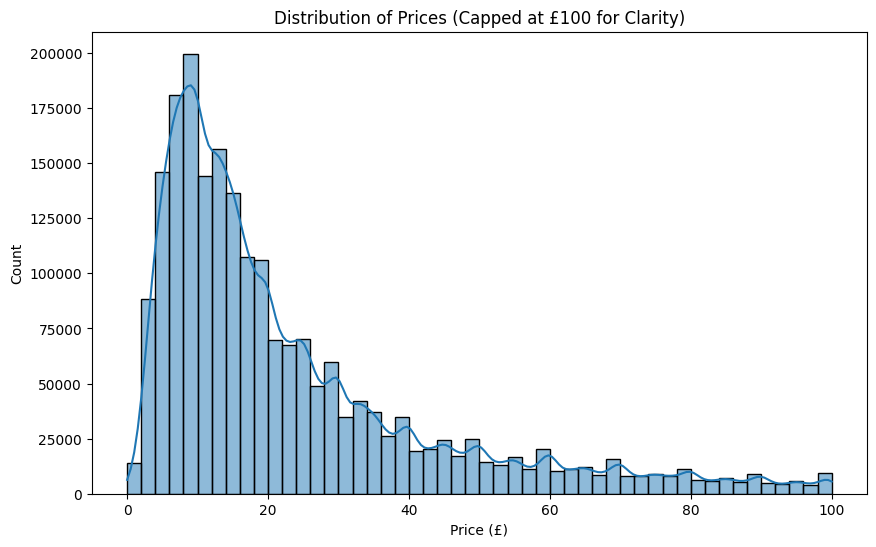

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(price_data[price_data < 100], bins=50, kde=True)
plt.title('Distribution of Prices (Capped at £100 for Clarity)')
plt.xlabel('Price (£)')
plt.show()

Histogram: La mayoría de los productos están por debajo de las £50. Si el gráfico es difícil de leer, es por los outliers (productos de £500+).
Solución: Aplicar un filtro para ver solo productos de 0 a 100 para observar mejor la tendencia masiva.

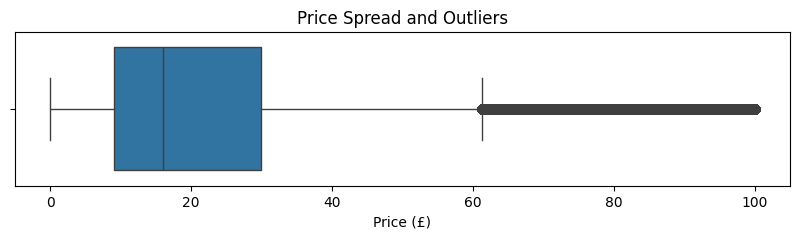

In [ ]:
# Price Boxplot
plt.figure(figsize=(10, 2))
sns.boxplot(x=price_data)
plt.title('Price Spread and Outliers')
plt.xlabel('Price (£)')
plt.show()


Sí hay muchos productos que se venden por entre £60 y £100.

In [ ]:
rating_data = df[df['stars'] > 0]['stars']
rating_stats = {
    'mean': rating_data.mean(),
    'median': rating_data.median(),
    'mode': rating_data.mode()[0],
    'var': rating_data.var(),
    'std': rating_data.std(),
    'iqr': rating_data.quantile(0.75) - rating_data.quantile(0.25),
    'skew': rating_data.skew(),
    'kurt': rating_data.kurtosis()
}

print("Top 5 Categories:\n", top_5_categories)
print("\nRating Stats:", rating_stats)

Top 5 Categories:
 category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Rating Stats: {'mean': np.float64(4.319160762226911), 'median': np.float64(4.4), 'mode': np.float64(4.5), 'var': np.float64(0.3083433752387284), 'std': np.float64(0.5552867504620729), 'iqr': np.float64(0.5), 'skew': np.float64(-2.379568112212799), 'kurt': np.float64(9.78193769066435)}


Mean: 4.32 estrellas.

Mode: 4.5 estrellas.

Tendencia: Los clientes tienden a calificar de forma muy positiva.

In [4]:
# Extraemos la serie limpia eliminando los ceros (ruido del dataset)
rating_data: pd.Series = df[df['stars'] > 0]['stars']

# Cálculos de dispersión
variance_rating: float = float(rating_data.var())
std_dev_rating: float = float(rating_data.std())
q1_rating: float = rating_data.quantile(0.25)
q3_rating: float = rating_data.quantile(0.75)
iqr_rating: float = float(q3_rating - q1_rating)

print("--- MEASURES OF DISPERSION (RATINGS) ---")
print(f"Variance           : {variance_rating:.4f}")
print(f"Standard Deviation : {std_dev_rating:.4f}")
print(f"Interquartile Range: {iqr_rating:.4f}")

NameError: name 'df' is not defined